## 1. Introduction

This section focuses on the analysis of **Indonesia’s economic indicators** from 1990 to 2021 using time series anomaly and change-point detection methods.  
The goal is to identify **unusual years or structural shifts** in key economic variables that may correspond to significant national or global events.

### Methodological Overview
**Anomaly detection** aims to find observations that deviate significantly from the general data pattern.  
Two approaches will be applied:
- **Z-Score method (statistical approach)** – detects outliers based on standard deviation thresholds.  
- **Isolation Forest (machine-learning approach)** – identifies anomalies by measuring how easily data points can be isolated in a decision-tree structure.

**Change-point detection** seeks to locate points in time where the statistical properties of a series (mean or variance) change significantly.  
This will be implemented using algorithms such as **PELT** from the `ruptures` library.

### Economic Indicators in the Dataset
The dataset includes five main indicators:

| Column | Description |
|:--|:--|
| **ggdp** | *Green Gross Domestic Product* — GDP adjusted for environmental factors. |
| **mil** | *Government Military Spending* — percentage of national budget or GDP devoted to defense. |
| **inf** | *Inflation Rate (%)* — annual percentage change in consumer prices. |
| **fdi** | *Foreign Direct Investment* — net inflow of foreign investment into Indonesia. |
| **gdp** | *Gross Domestic Product* — total monetary value of goods and services produced annually. |

## 2. Detecting anomalies – Z-Score

### 2.1 Overview
The **Z-Score method** is a statistical technique used to identify anomalies in a time series by measuring how far each observation deviates from the mean.

For a given observation \( x_i \):
\[
Z_i = \frac{x_i - \mu}{\sigma}
\]
where:
- \( \mu \) = mean of the series  
- \( \sigma \) = standard deviation of the series  

If \( |Z_i| > 3 \), the data point is considered an **anomaly**.

### 2.2 Objectives
In this section, we will:
1. Compute Z-Scores for each economic indicator in the dataset (`ggdp`, `mil`, `inf`, `fdi`, `gdp`).
2. Identify outliers (|Z| > 3).
3. Visualize anomalies on time series plots.
4. Summarize the detected abnormal years.


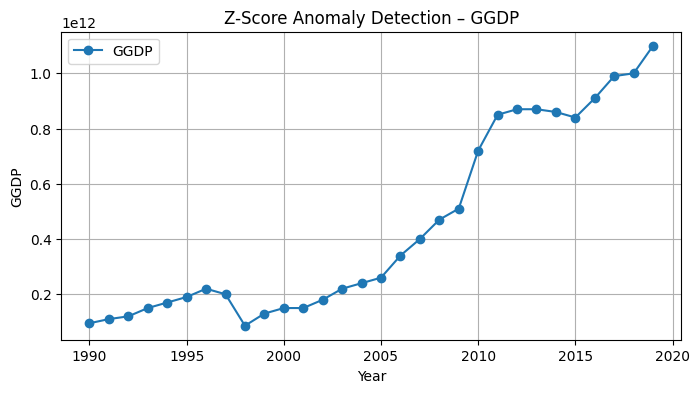

🔹 GGDP – Anomalies detected at years: None


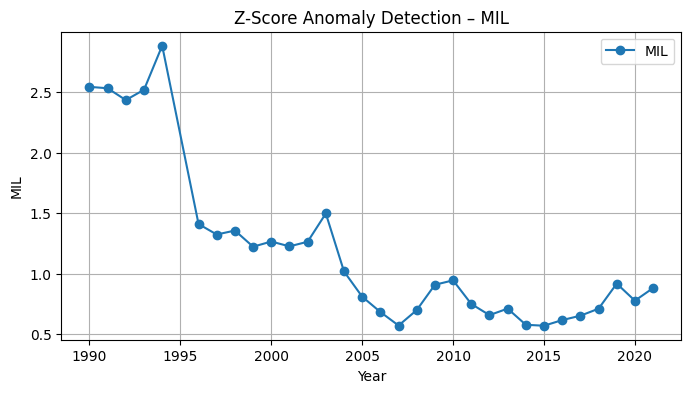

🔹 MIL – Anomalies detected at years: None


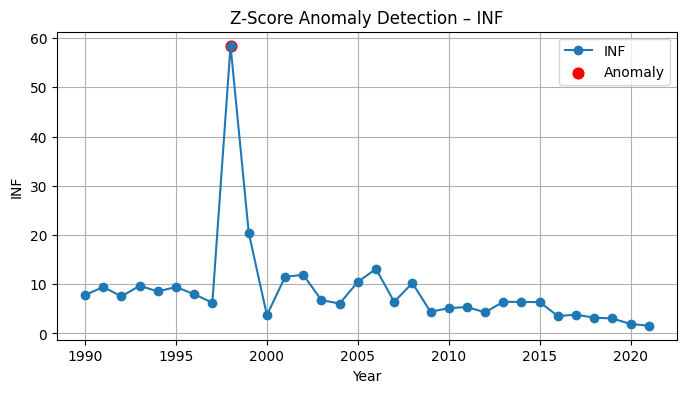

🔹 INF – Anomalies detected at years: [1998]


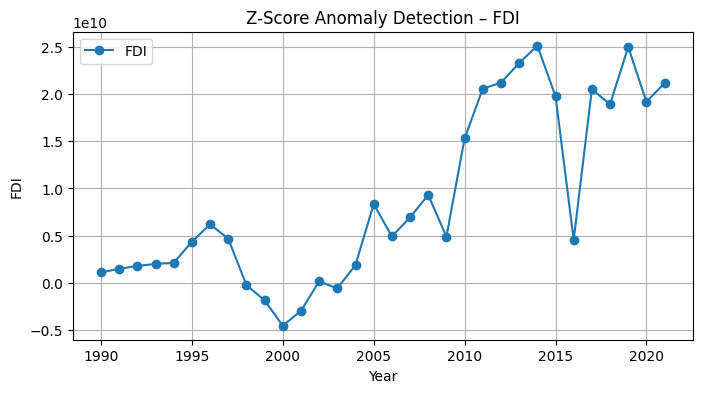

🔹 FDI – Anomalies detected at years: None


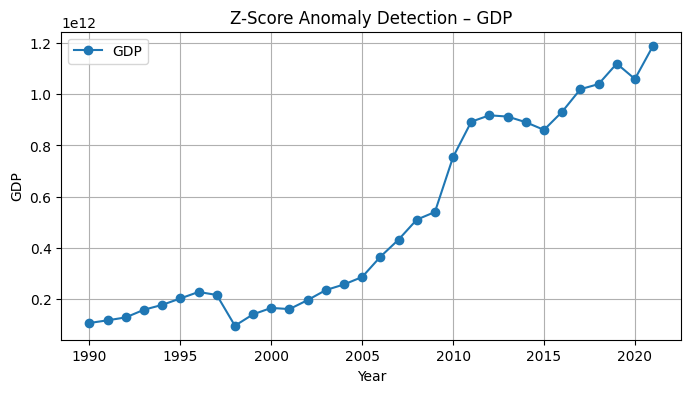

🔹 GDP – Anomalies detected at years: None


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Data02_05_Indonesia_C.csv")

# Hàm tính Z-score và phát hiện anomaly
def detect_zscore_anomalies(series, threshold=3):
    clean_series = series.dropna()  # loại bỏ NaN
    z = (clean_series - clean_series.mean()) / clean_series.std()
    anomalies = clean_series[np.abs(z) > threshold]
    return anomalies, z

# Các biến kinh tế cần xét
indicators = ["ggdp", "mil", "inf", "fdi", "gdp"]

# Chạy Z-score cho từng biến
for col in indicators:
    # Giữ lại dữ liệu không NaN, đồng thời reset index để đồng bộ
    data = df[["year", col]].dropna(subset=[col]).reset_index(drop=True)
    anomalies, z = detect_zscore_anomalies(data[col])
    
    plt.figure(figsize=(8,4))
    plt.plot(data["year"], data[col], marker='o', label=f"{col.upper()}")
    
    # Nếu có anomaly thì highlight đúng vị trí
    if not anomalies.empty:
        anomaly_years = data.loc[anomalies.index, "year"].values
        anomaly_values = anomalies.values
        plt.scatter(anomaly_years, anomaly_values, color='red', s=60, label="Anomaly")
    
    plt.title(f"Z-Score Anomaly Detection – {col.upper()}")
    plt.xlabel("Year"); plt.ylabel(col.upper())
    plt.legend(); plt.grid(True); plt.show()
    
    # In năm bị phát hiện bất thường
    years = data.loc[anomalies.index, "year"].tolist()
    print(f"🔹 {col.upper()} – Anomalies detected at years: {years if years else 'None'}")

## 3. Detecting anomalies – Isolation Forest

### 3.1 Overview
The **Isolation Forest** is a machine learning–based anomaly detection algorithm.  
It works by randomly partitioning the data into smaller subsets.  
Data points that can be isolated more quickly (requiring fewer random splits) are considered **anomalies**.

Unlike the Z-Score method, which relies on the assumption of a normal distribution,  
the Isolation Forest can handle **non-linear** and **non-Gaussian** data —  
making it suitable for detecting irregular patterns in economic indicators.

### 3.2 Objectives
In this section, we will:
1. Apply the Isolation Forest algorithm to each indicator (`ggdp`, `mil`, `inf`, `fdi`, `gdp`).
2. Identify and visualize anomalous years.
3. Compare results with the Z-Score method.


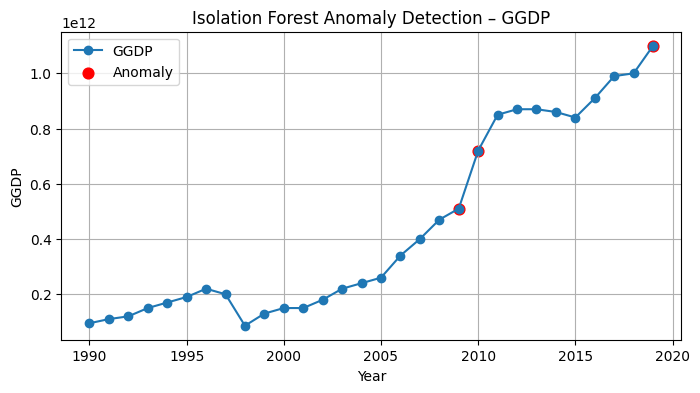

🔹 GGDP – Anomalies detected at years: [2009, 2010, 2019]


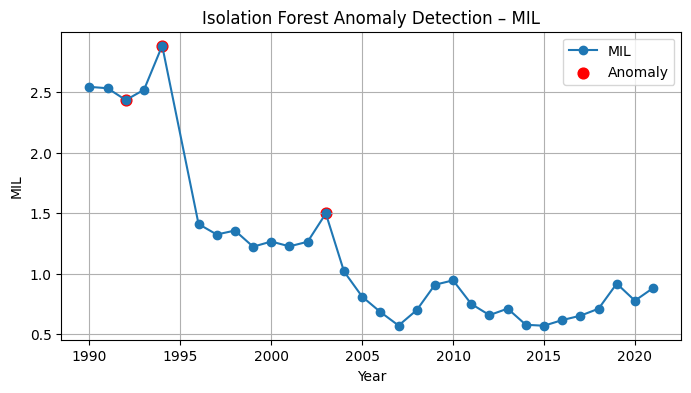

🔹 MIL – Anomalies detected at years: [1992, 1994, 2003]


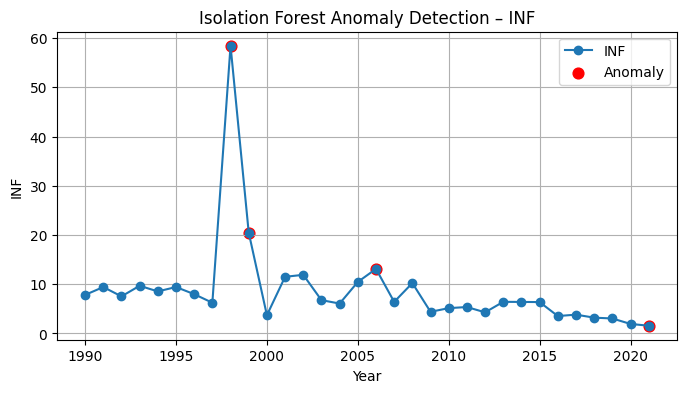

🔹 INF – Anomalies detected at years: [1998, 1999, 2006, 2021]


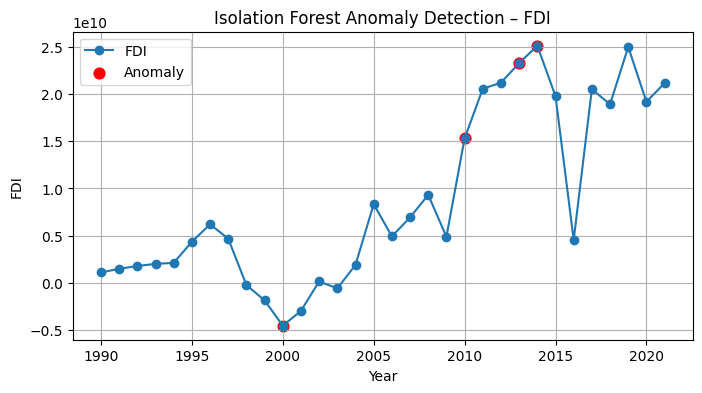

🔹 FDI – Anomalies detected at years: [2000, 2010, 2013, 2014]


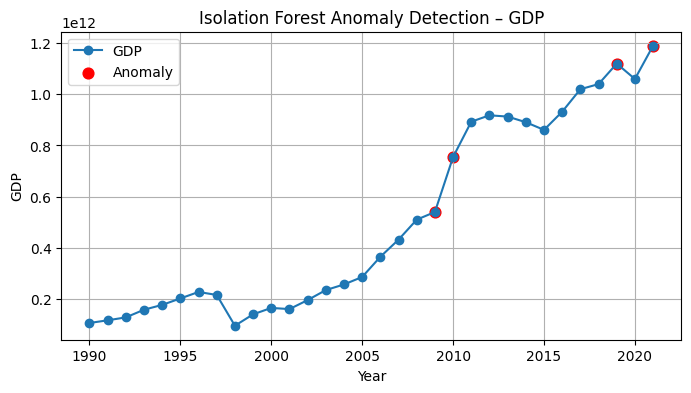

🔹 GDP – Anomalies detected at years: [2009, 2010, 2019, 2021]


In [3]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt

# Các chỉ số kinh tế
indicators = ["ggdp", "mil", "inf", "fdi", "gdp"]

# Áp dụng Isolation Forest cho từng biến
for col in indicators:
    data = df[["year", col]].dropna(subset=[col]).reset_index(drop=True)
    X = data[[col]].values  # mô hình chỉ cần 1 cột giá trị
    
    # Tạo model Isolation Forest
    iso = IsolationForest(contamination=0.1, random_state=42)
    preds = iso.fit_predict(X)  # -1 = outlier, 1 = normal
    
    # Xác định index của anomaly
    anomaly_index = np.where(preds == -1)[0]
    
    # Vẽ biểu đồ
    plt.figure(figsize=(8,4))
    plt.plot(data["year"], data[col], marker='o', label=f"{col.upper()}")
    if len(anomaly_index) > 0:
        plt.scatter(data.loc[anomaly_index, "year"], data.loc[anomaly_index, col], 
                    color='red', s=60, label="Anomaly")
    plt.title(f"Isolation Forest Anomaly Detection – {col.upper()}")
    plt.xlabel("Year"); plt.ylabel(col.upper())
    plt.legend(); plt.grid(True); plt.show()
    
    # In ra năm anomaly
    anomaly_years = data.loc[anomaly_index, "year"].tolist()
    print(f"🔹 {col.upper()} – Anomalies detected at years: {anomaly_years if anomaly_years else 'None'}")
